PROYECTO FINAL: PARTE 3

APRENDIZAJE NO SUPERVISADO

In [1]:
#LIBRERÍAS

import pandas as pd
import numpy as np

#visualización
import matplotlib.pyplot as plt
import seaborn as sns

#preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#reducción de dimensionalidad
from sklearn.decomposition import PCA

#clustering
from sklearn.cluster import KMeans

In [2]:
#cargamos los datos
df = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

In [3]:
#vemos las primera filas
df.head()

,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


SELECCIÓN DE VARIABLES

Para el análisis no supervisado seleccionamos un subconjunto de variables que describen al estudiante antes de conocer su resultado final. 

En particular, eliminamos la variable objetivo y las variables del segundo semestre para evitar incorporar información que refleje directamente el resultado académico

In [4]:
#eliminamos target
df_unsup = df.drop(columns=['objetivo'])

#eliminamos las variables del segundo semestre
cols_2sem = [col for col in df_unsup.columns if '2sem' in col]
df_unsup = df_unsup.drop(columns=cols_2sem)

In [5]:
#separamos variables numéricas y categóricas
#variables numéricas
numeric_cols = df_unsup.select_dtypes(include=['int64', 'float64']).columns

#variables categoricas
categoric_cols = df_unsup.select_dtypes(include=['object']).columns

In [ ]:
#preprocesamos
#definimos preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoric_cols)
    ]
)

#transformamos datos
X_processed = preprocessor.fit_transform(df_unsup)

Shape (4424, 249)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    442

PCA

Nuestro objetivo es reducir dimensiones, visualizar la estructura de los datos y detectar patrones

In [7]:
#convertimos a matriz densa
X_dense = X_processed.toarray()

#aplicamos PCA a 2 componentes
pca = PCA()

X_pca = pca.fit_transform(X_dense)

In [8]:
#varianza explicada por cada componente
print(pca.explained_variance_ratio_)

#varianza acumulada
print(np.cumsum(pca.explained_variance_ratio_))

[1.62311382e-01 9.78822926e-02 8.11494347e-02 6.40498003e-02
 5.44751715e-02 5.10912820e-02 3.98716683e-02 3.82638537e-02
 2.91635164e-02 2.59798638e-02 2.17874990e-02 2.03422124e-02
 1.89224437e-02 1.66759163e-02 1.46203647e-02 1.32716169e-02
 1.29164454e-02 1.24235355e-02 1.11585220e-02 1.06467143e-02
 9.62178223e-03 9.05158265e-03 8.72010844e-03 8.20188340e-03
 7.91614205e-03 7.20437076e-03 7.15514145e-03 6.08146314e-03
 5.91126575e-03 5.68864476e-03 5.24797920e-03 5.13131512e-03
 5.07263218e-03 4.59975836e-03 4.42580793e-03 4.36663239e-03
 4.21863598e-03 4.01819555e-03 3.96083553e-03 3.70190598e-03
 3.64817478e-03 3.62774078e-03 3.37763348e-03 3.33192023e-03
 3.26348671e-03 3.09350215e-03 3.03325049e-03 2.94562526e-03
 2.80187836e-03 2.74875763e-03 2.70243396e-03 2.57433248e-03
 2.45527571e-03 2.31587313e-03 2.21622926e-03 2.01972002e-03
 1.93969469e-03 1.80621521e-03 1.73651340e-03 1.62512052e-03
 1.52229121e-03 1.37643377e-03 1.32287364e-03 1.24658649e-03
 1.19936871e-03 1.129613

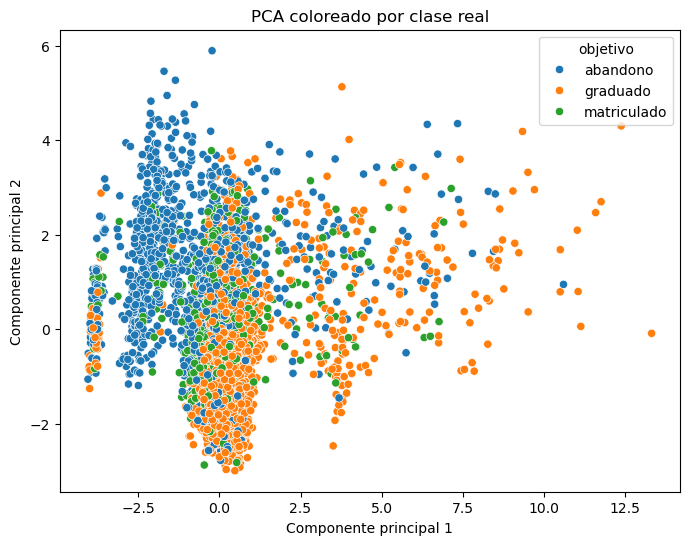

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['objetivo'])

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('PCA coloreado por clase real')

plt.show()

La aplicación del análisis de componentes principales (PCA) ha permitido reducir la dimensionalidad del conjunto de datos y facilitar su visualización en un espacio bidimensional.

En particular, la primera componente principal explica aproximadamente un 16.23% de la varianza total, mientras que la segunda componente explica un 9.78%. En conjunto, ambas componentes acumulan alrededor del 26.02% de la varianza total del dataset.

Este resultado indica que una parte relevante de la información original se conserva en estas dos dimensiones, aunque la mayor parte de la variabilidad permanece distribuida en otras componentes no representadas. Esto es esperable en datasets de alta dimensionalidad, especialmente cuando incluyen variables categóricas codificadas mediante one-hot encoding.

La representación gráfica de los datos en el espacio de las dos primeras componentes principales no muestra una separación nítida entre las clases de estudiantes (abandono, matriculado y graduado), lo que sugiere que las diferencias entre estos perfiles no son linealmente separables en un espacio de baja dimensión.

No obstante, sí se pueden identificar ciertos patrones relevantes. En primer lugar, los estudiantes graduados presentan una mayor dispersión, especialmente a lo largo de la primera componente principal, lo que sugiere una mayor heterogeneidad en sus características. Por el contrario, los estudiantes que abandonan tienden a concentrarse en regiones más específicas del espacio, indicando un perfil más homogéneo. Finalmente, los estudiantes matriculados se sitúan mayoritariamente en posiciones intermedias, reflejando su naturaleza transicional entre ambas situaciones.

En conjunto, estos resultados ponen de manifiesto que, aunque existen tendencias estructurales en los datos, la separación entre los distintos tipos de estudiantes es compleja y no puede capturarse completamente mediante una proyección en dos dimensiones. Esto refuerza la necesidad de emplear técnicas más avanzadas, como métodos de clustering o modelos supervisados, para identificar patrones más precisos en la trayectoria académica del alumnado.

CLUSTERING

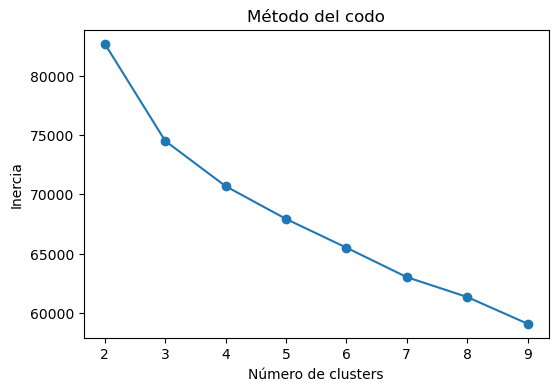

In [10]:
#elegimos el número de clusters por el método del codo
inertia = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.show()

Para determinar el número óptimo de clusters se ha utilizado el método del codo, que consiste en analizar la evolución de la inercia en función del número de clusters.

Tal y como se observa en la figura, la reducción de la inercia es significativa al pasar de 2 a 3 clusters, mientras que a partir de este punto la mejora se vuelve progresivamente menor y más suave. Este comportamiento indica la presencia de un “codo” en torno a k=3, lo que sugiere que este es un número adecuado de clusters.

Por tanto, se ha seleccionado k=3 como compromiso entre simplicidad del modelo y capacidad de representación de la estructura de los datos. Además, esta elección resulta coherente con la naturaleza del problema, en el que se distinguen tres posibles trayectorias académicas del estudiante.

In [11]:
#entrenamos KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_processed)

df['cluster'] = clusters

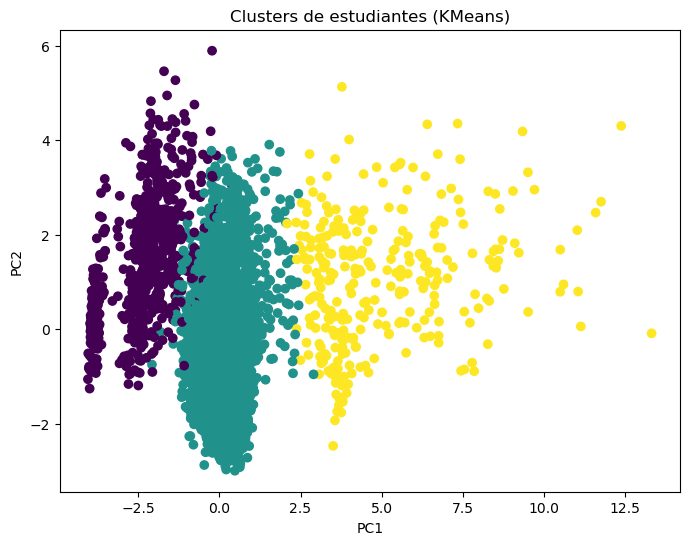

In [12]:
#visualizamos clusters en PCA

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')

plt.title('Clusters de estudiantes (KMeans)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

La aplicación de K-Means con k=3 ha permitido identificar tres grupos diferenciados de estudiantes. En la representación mediante PCA se observa que los clusters se organizan principalmente a lo largo de la primera componente principal (PC1), lo que indica que esta dimensión concentra gran parte de la variabilidad relevante.

En particular, se distinguen claramente tres regiones: un grupo situado en valores negativos de PC1, otro en torno a valores centrales y un tercero desplazado hacia valores positivos, este último con mayor dispersión.

Esta estructura sugiere la existencia de perfiles de estudiantes diferenciados, lo que pone de manifiesto que el modelo ha sido capaz de capturar patrones relevantes en los datos incluso sin utilizar información supervisada.

In [13]:
df.groupby('cluster').mean(numeric_only=True)

,orden_solicitud,nota_cualificacion_previa,nota_admision,edad_al_matricularse,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
cluster,,,,,,,,,,,,,,,,,,,
0,1.576552,132.724552,126.900552,25.768276,0.005517,4.160000,3.826207,0.015172,0.102069,0.252414,0.008276,4.256552,3.268966,0.113103,0.730601,0.252414,11.575034,1.313931,-0.224014
1,1.810628,132.661362,126.790634,22.215796,0.188197,6.136524,8.534351,5.126248,12.713608,0.087786,0.147974,6.225191,8.556958,4.911039,12.048678,0.115972,11.586406,1.195156,0.061066
2,1.139932,131.779522,129.349488,29.269625,8.518771,13.051195,16.631399,11.436860,12.622686,0.433447,6.440273,11.201365,14.187713,9.607509,12.597094,0.296928,11.308532,1.397611,-0.125836


El análisis de los clusters obtenidos mediante K-Means permite identificar tres perfiles diferenciados de estudiantes en función de su rendimiento académico y características iniciales.

El cluster 2 se caracteriza por un mayor número de asignaturas matriculadas, evaluadas y aprobadas en el primer semestre, así como por una nota media elevada. Este grupo presenta también mejores resultados en el segundo semestre, lo que sugiere que está compuesto por estudiantes con alto rendimiento académico y mayor probabilidad de éxito.

El cluster 1 presenta valores intermedios en la mayoría de las variables académicas, con un número moderado de asignaturas aprobadas y calificaciones medias relativamente buenas. Este grupo puede interpretarse como un perfil de estudiantes con rendimiento medio y trayectoria académica incierta.

Por su parte, el cluster 0 muestra un rendimiento académico muy bajo, con un número prácticamente nulo de asignaturas aprobadas en el primer semestre y una nota media muy reducida. Además, también presenta peores resultados en el segundo semestre, lo que sugiere que este grupo está asociado a estudiantes con mayor riesgo de abandono.

En conjunto, estos resultados indican que el rendimiento en el primer semestre es un factor clave para diferenciar perfiles de estudiantes, incluso sin utilizar información supervisada. El clustering ha sido capaz de capturar patrones relevantes en los datos, identificando grupos coherentes que reflejan distintos niveles de desempeño académico.

HEATMAP DE PERFILES

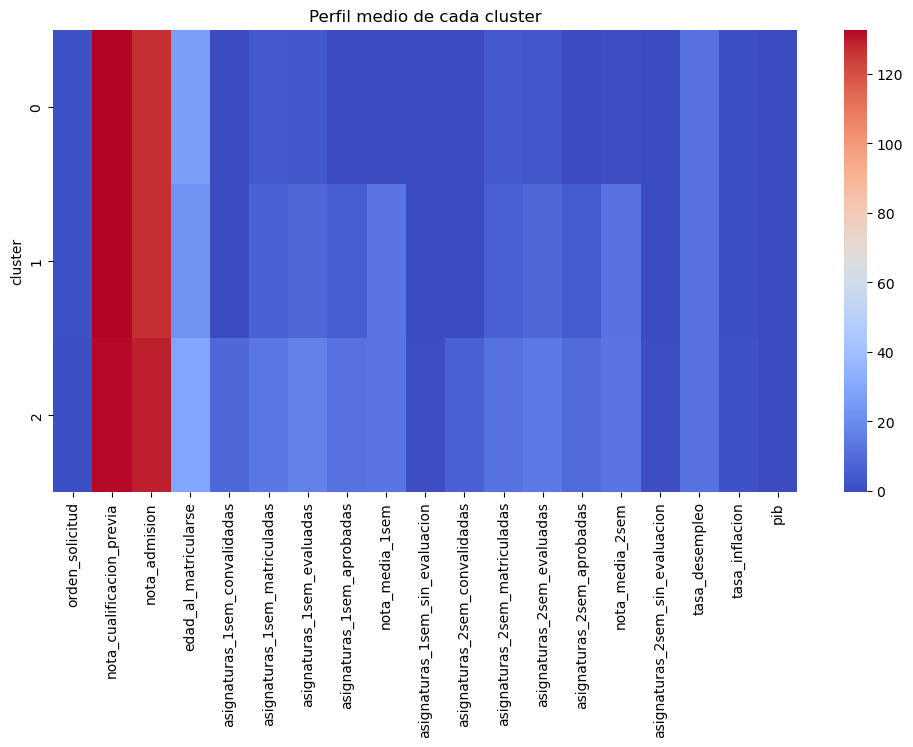

In [14]:
cluster_means = df.groupby('cluster').mean(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap='coolwarm', annot=False)

plt.title('Perfil medio de cada cluster')
plt.show()

El mapa de calor permite visualizar de forma global las diferencias entre los perfiles medios de cada cluster. Se observa que las principales variaciones se concentran en las variables relacionadas con el rendimiento académico, especialmente en el número de asignaturas matriculadas, evaluadas y aprobadas, así como en las calificaciones medias.

En particular, el cluster 2 presenta valores más elevados en estas variables, lo que confirma que corresponde a estudiantes con mejor rendimiento académico. Por el contrario, el cluster 0 muestra valores significativamente más bajos, reflejando un perfil de bajo rendimiento. El cluster 1 se sitúa en una posición intermedia, con características más moderadas.

Por otro lado, variables como las condiciones macroeconómicas apenas muestran diferencias entre clusters, lo que sugiere que tienen menor capacidad discriminativa en la segmentación de los estudiantes.

En conjunto, este análisis refuerza la idea de que el rendimiento en el primer semestre es el principal factor que define los distintos perfiles de estudiantes identificados.

In [15]:
#comparamos clusters con la variable real
pd.crosstab(df['cluster'], df['objetivo'], normalize='index')

objetivo,abandono,graduado,matriculado
cluster,,,
0,0.794483,0.106207,0.099310
1,0.226952,0.572225,0.200822
2,0.245734,0.624573,0.129693


Para evaluar la relevancia de los clusters obtenidos, se ha analizado su correspondencia con la variable objetivo. Los resultados muestran una clara diferenciación entre los perfiles identificados:

-El cluster 0 está fuertemente asociado al abandono, con aproximadamente un 79% de estudiantes en esta categoría, lo que confirma que representa un perfil de alto riesgo académico.

-Los clusters 1 y 2 presentan una mayor proporción de estudiantes graduados (alrededor del 57% y 62% respectivamente), lo que indica que están asociados a trayectorias académicas exitosas.

El porcentaje de estudiantes matriculados es menor en todos los clusters, situándose como un estado intermedio entre abandono y graduación.

En conjunto, estos resultados demuestran que el modelo de clustering ha sido capaz de identificar grupos con un significado claro en términos de la variable objetivo, a pesar de no haber utilizado dicha información durante el entrenamiento.